In [ ]:
!pip install -U classiq
!pip install keyrings.alt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.1/657.1 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: zstandard
    Found existing installation: zstandard 0.25.0
    Uninstalling zstandard-0.25.0:
      Successfully uninstalled zstandard-0.25.0
  Attempting uninstall: pyomo
    Found existing installation: pyomo 6.10.0
    Uninstalling pyomo-6.10.0:
      Successfully 

In [20]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [22]:
import classiq
classiq.authenticate(overwrite=True)

If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DGDLX-GQQJ&scope=offline_access
Your user code: GDLX-GQQJ


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from tabulate import tabulate

from classiq import *

In [24]:
# Inputs
n = 2  # dimension of vectors x(0) and b
t = 1
M = np.array([[0, 1], [-1, 0]])
x_0 = [1, 1]
b = [0, 0]

# Constants
k = 7
x_0_norm = np.linalg.norm(x_0)
b_norm = np.linalg.norm(b)
M_norm = np.linalg.norm(M)
# A = np.multiply(1/np.linalg.norm(M), M)
A = M

In [25]:
vs1 = []
c = 0


def VS1(t):
    global vs1
    global c
    c = 0
    c_m = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        c_m[i] = (x_0_norm * (pow(t, i))) / m_factorial
        # c_m[i] = (x_0_norm * (pow(t * M_Norm, i))) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1

    c = np.sqrt(c)

    if t == 0:
        vs1 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(c_m[i]) / c for i in range(k + 1)], e)
    vs1 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [26]:
vs2 = []
d = 0


def VS2():
    global vs2
    global d
    d = 0
    d_m = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        d_m[i - 1] = (b_norm * (pow(t * M_norm, i - 1))) / n_factorial
        d += d_m[i - 1]
        n_factorial *= i + 1
    d_m[k] = 0
    d = np.sqrt(d)

    if d == 0:
        vs2 = np.eye(k + 1, k + 1)
        return
    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(d_m[i]) / d for i in range(k + 1)], e)
    vs2 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [27]:
v = []
N = 0


def V():
    global v
    global N
    v = []
    N = np.sqrt(c * c + d * d)
    if N == 0:
        v = np.eye(2, 2)
    else:
        v.append([c / N, d / N])
        v.append([d / N, -c / N])
        v = np.array(v)

In [28]:
@qfunc
def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
    prob_x_0 = []
    for i in x_0:
        prob_x_0.append(i / x_0_norm)
    inplace_prepare_amplitudes(prob_x_0, 0.01, x)

    VS1(t)
    VS2()
    V()

    unitary(v, y)
    control(y == 0, lambda: unitary(vs1, ancilla), lambda: unitary(vs2, ancilla))

In [29]:
@qfunc
def evolution(x: QNum, ancilla: QNum):
    u_m = np.array([[1, 0], [0, 1]])

    for i in range(k + 1):
        U = u_m.copy()
        control(ancilla == i, lambda U=U: unitary(U, x))
        u_m = u_m @ A

In [30]:
@qfunc
def decoding(ancilla: QNum, y: QBit):
    ws1 = vs1.conj().T
    ws2 = vs2.conj().T
    w = v.conj().T
    control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
    unitary(w, y)

In [31]:
T = int(np.log2(k + 1))  # no of ancilla qubits
dim = int(np.log2(n))  # no of work qubits


def create_main_for_t(t: float):
    @qfunc
    def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
        allocate(x)
        allocate(ancilla)
        allocate(y)

        encoding(x, ancilla, y, t)
        evolution(x, ancilla)
        decoding(ancilla, y)

    return main

In [32]:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

In [37]:
omega = 1
y = []
y_dash = []
t_end = 10
t0 = np.pi/omega
dt = t0/50
n_steps = int(t_end/dt) if t_end <= t0 else int(t0/dt)
print(n_steps)

for i in range(n_steps + 1):
    t = i * dt
    print(t)
    qmod = create_model(create_main_for_t(t))
    qmod = set_execution_preferences(qmod, execution_preferences)
    qprog = synthesize(qmod)
    job = execute(qprog)
    results = job.result_value()
    for j in results.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash.append(np.linalg.norm(j.amplitude) * (N * N))

49
0.0
00000  :  1.0000000000000073
00001  :  0.9999999999999913
0.06283185307179587
00000  :  1.0608172479575844
00001  :  0.9352362088989425
0.12566370614359174
00000  :  1.117447934877226
00001  :  0.8667814677486392
0.1884955592153876
00000  :  1.1696685652740824
00001  :  0.7949059361042566
0.25132741228718347
00000  :  1.2172730478879301
00001  :  0.7198932735802337
0.3141592653589793
00000  :  1.2600735082373107
00001  :  0.6420395196515459
0.3769911184307752
00000  :  1.2979010280468046
00001  :  0.5616519235240395
0.4398229715025711
00000  :  1.3306063076815686
00001  :  0.4790477279398811
0.5026548245743669
00000  :  1.358060247722976
00001  :  0.3945529107836847
0.5654866776461628
00000  :  1.3801544458196564
00001  :  0.3085008883559015
0.6283185307179586
00000  :  1.3968016049476244
00001  :  0.22123118417891097
0.6911503837897546
00000  :  1.4079358492137963
00001  :  0.13308806720208854
0.7539822368615504
00000  :  1.4135129433368367
00001  :  0.044419163271748
0.8168140

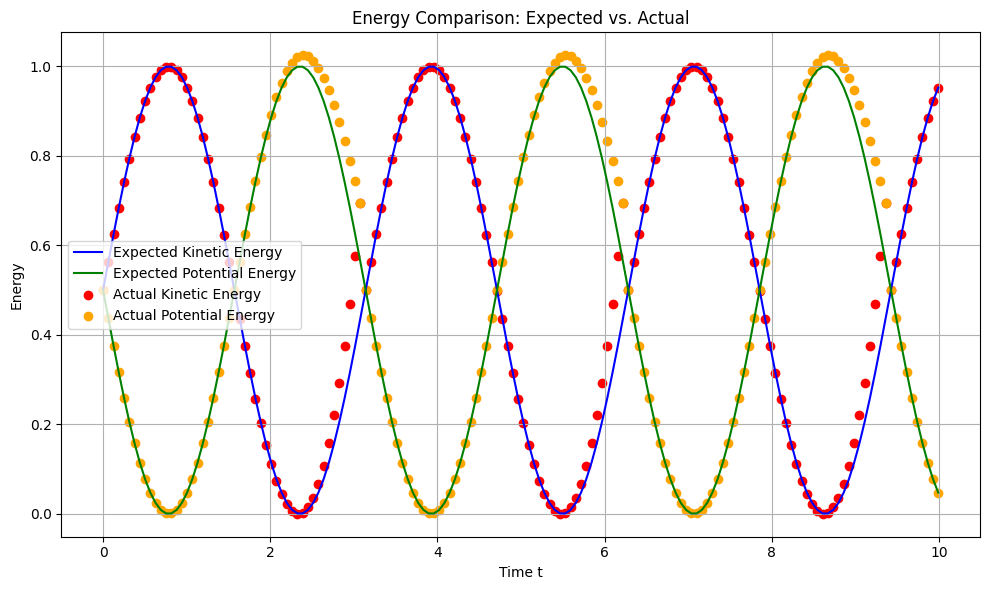

In [38]:
t_values = [i * dt for i in range(round(t_end / dt) + 1)]
def lookup(t, base):
    idx = round((t % t0) / dt)
    return base[idx]

y1      = [lookup(t, y)      for t in t_values]
y_dash1 = [lookup(t, y_dash) for t in t_values]

# Expected energies calculated from the formulas
y_values = [np.sin(t) + np.cos(t) for t in t_values]
ydash_values = [np.cos(t) - np.sin(t) for t in t_values]

kinetic_expected = [(y**2) / 2 for y in y_values]
potential_expected = [(ydash**2) / 2 for ydash in ydash_values]


# Actual energies calculated from algorithm outputs:
kinetic_actual = [(y_val**2) / 2 for y_val in y1]
potential_actual = [(ydash_val**2) / 2 for ydash_val in y_dash1]


plt.figure(figsize=(10, 6))


plt.plot(
    t_values,
    kinetic_expected,
    label="Expected Kinetic Energy",
    color="blue",
    linestyle="-",
)
plt.plot(
    t_values,
    potential_expected,
    label="Expected Potential Energy",
    color="green",
    linestyle="-",
)


plt.scatter(
    t_values, kinetic_actual, label="Actual Kinetic Energy", color="red", marker="o"
)
plt.scatter(
    t_values,
    potential_actual,
    label="Actual Potential Energy",
    color="orange",
    marker="o",
)


plt.xlabel("Time t")
plt.ylabel("Energy")
plt.title("Energy Comparison: Expected vs. Actual")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
results = [
    [
        i * dt,
        kinetic_expected[i],
        kinetic_actual[i],
        potential_expected[i],
        potential_actual[i],
    ]
    for i in range(round(t_end / dt) + 1)
]
table = tabulate(
    results,
    headers=[
        "t",
        "Kinetic expected",
        "Kinetic actual",
        "Potential expected",
        "Potential actual)",
    ],
    numalign="center",
    tablefmt="github",
)
print(table)

error_bound_potential = [
    100 * np.abs(a - e) / a for a, e in zip(potential_expected, potential_actual)
]
error_bound_kinetic = [
    100 * np.abs(a - e) / a for a, e in zip(kinetic_expected, kinetic_actual)
]

print("\n\nkinetic accuracy (Mean): ", 100 - np.mean(error_bound_kinetic), "%")
print("potential accuracy (Mean): ", 100 - np.mean(error_bound_potential), "%")

|     t     |  Kinetic expected  |  Kinetic actual  |  Potential expected  |  Potential actual)  |
|-----------|--------------------|------------------|----------------------|---------------------|
|     0     |        0.5         |       0.5        |         0.5          |         0.5         |
| 0.0628319 |      0.562667      |     0.562667     |       0.437333       |      0.437333       |
| 0.125664  |      0.624345      |     0.624345     |       0.375655       |      0.375655       |
| 0.188496  |      0.684062      |     0.684062     |       0.315938       |      0.315938       |
| 0.251327  |      0.740877      |     0.740877     |       0.259123       |      0.259123       |
| 0.314159  |      0.793893      |     0.793893     |       0.206107       |      0.206107       |
| 0.376991  |      0.842274      |     0.842274     |       0.157726       |      0.157726       |
| 0.439823  |      0.885257      |     0.885257     |       0.114743       |      0.114743       |
| 0.502655